# Student Performance Analysis  
### Exploring the Impact of Study Time and Absences on Final Grades

Author: Shend Hoda

## 1. Import Libraries

In [2]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load Dataset

In [4]:
# Load dataset

df = pd.read_csv("/Users/shend/Desktop/FinalProject/student/student-mat.csv", sep=';')

# Preview first rows of dataset

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 3. Data Exploration

In [5]:
# Data Overview

print("Shape:", df.shape)
df.info()
df.describe()

Shape: (395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    objec

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [6]:
# Missing Values

df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

## 4. Exploratory Data Analysis (EDA)

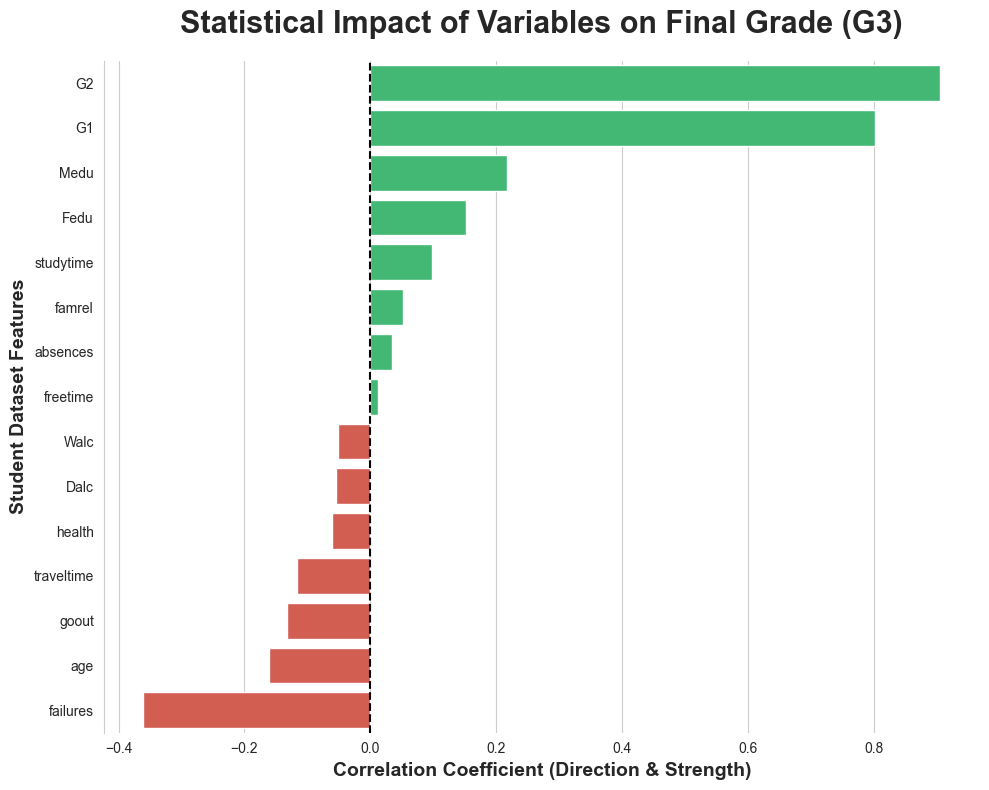

In [7]:
# Correlation Analysis

grade_corr = df.corr(numeric_only=True)['G3'].sort_values(ascending=False)

grade_corr = grade_corr.drop('G3')

plt.figure(figsize=(10, 8))

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in grade_corr.values]

sns.barplot(
    x=grade_corr.values, 
    y=grade_corr.index, 
    palette=colors,
    hue=grade_corr.index,
    legend=False
)

plt.title("Statistical Impact of Variables on Final Grade (G3)", fontsize=22, fontweight='bold', pad=20)
plt.xlabel("Correlation Coefficient (Direction & Strength)", fontsize=14, fontweight='bold')
plt.ylabel("Student Dataset Features", fontsize=14, fontweight='bold')

plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')

sns.despine(left=False, bottom=True)

plt.tight_layout()
plt.savefig("CorrelationAnalysis.png", dpi=300)
plt.show()

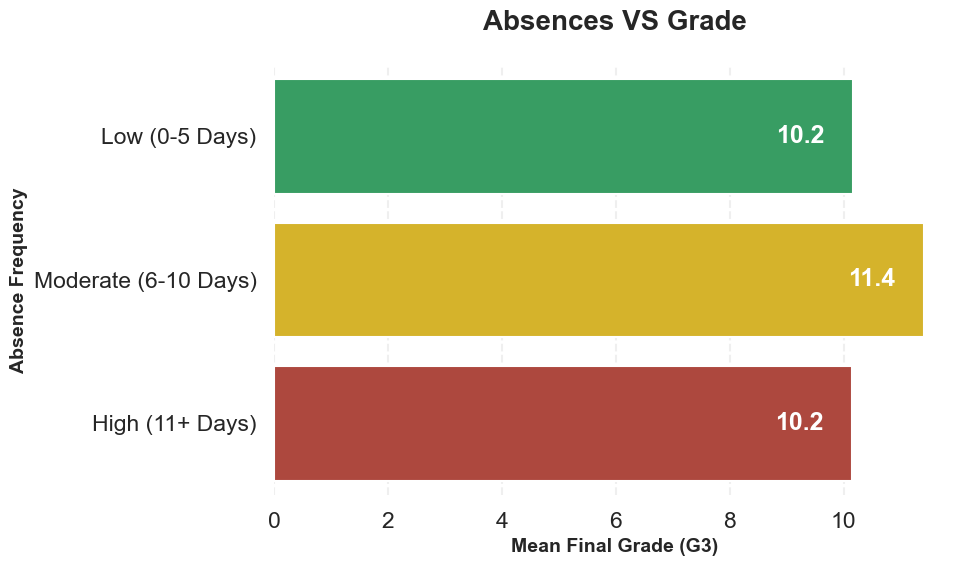

In [8]:
# Absences VS Grade

sns.set_theme(style="white", context="talk")

df['Absence_Group'] = pd.cut(
    df['absences'], 
    bins=[-1, 5, 10, 100], 
    labels=['Low (0-5 Days)', 'Moderate (6-10 Days)', 'High (11+ Days)']
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='G3',
    y='Absence_Group',
    data=df,
    hue='Absence_Group',
    palette=['#27ae60', '#f1c40f', '#c0392b'],
    errorbar=None,
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    plt.text(
        width - 0.5,
        p.get_y() + p.get_height()/2,
        f'{width:.1f}',
        va='center',
        ha='right',
        color='white',
        fontweight='bold'
    )

plt.title("Absences VS Grade", fontsize=20, fontweight='bold', pad=25)
plt.xlabel("Mean Final Grade (G3)", fontsize=14, fontweight='semibold')
plt.ylabel("Absence Frequency", fontsize=14, fontweight='semibold')

sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("absences_vs_grade.png", dpi=300)
plt.show()

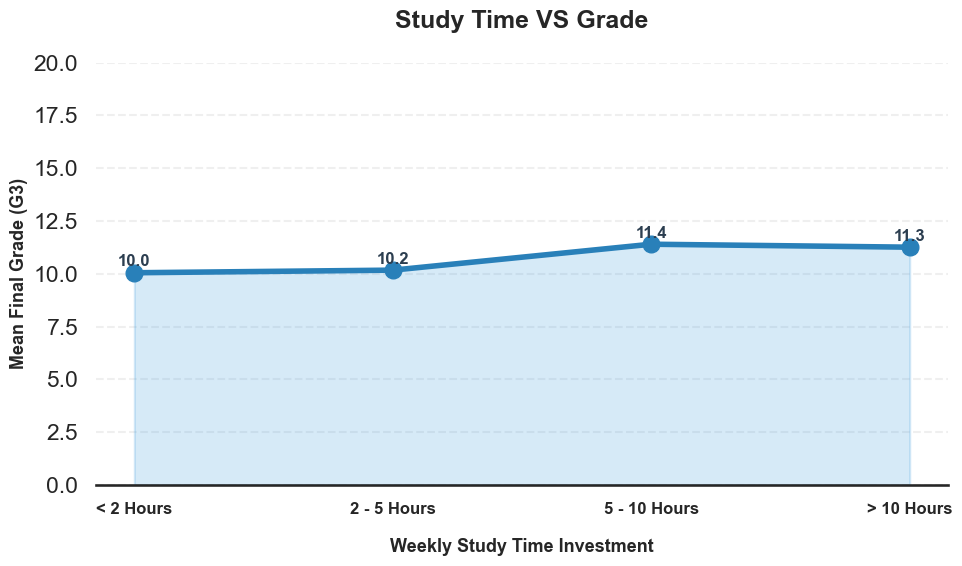

In [9]:
# Study Time VS Grade

study_means = df.groupby('studytime', as_index=False)['G3'].mean()

study_labels = [
    '< 2 Hours',
    '2 - 5 Hours',
    '5 - 10 Hours',
    '> 10 Hours'
]

plt.figure(figsize=(10, 6))

plt.plot(study_means['studytime'], study_means['G3'], color='#2980b9', marker='o', linewidth=4, markersize=12)
plt.fill_between(study_means['studytime'], study_means['G3'], alpha=0.2, color='#3498db')

for _, row in study_means.iterrows():
    plt.text(
        row['studytime'],
        row['G3'] + 0.3,
        f"{row['G3']:.1f}",
        color='#2c3e50',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title("Study Time VS Grade", fontsize=18, fontweight='bold', pad=25)

plt.xticks(study_means['studytime'], study_labels, fontsize=12, fontweight='semibold')

plt.xlabel("Weekly Study Time Investment", fontsize=13, fontweight='semibold', labelpad=15)
plt.ylabel("Mean Final Grade (G3)", fontsize=13, fontweight='semibold')

plt.ylim(0, 20)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.savefig("studytime_vs_grade.png", dpi=300)
plt.show()

In [10]:
# Insights

print("Correlation (Absences vs Grade):", df['absences'].corr(df['G3']))
print("Correlation (Study Time vs Grade):", df['studytime'].corr(df['G3']))

Correlation (Absences vs Grade): 0.034247316150069325
Correlation (Study Time vs Grade): 0.09781968965319626


## 5. Modeling

In [11]:
# Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X = df[['absences', 'studytime']]
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 3.734360882680873


## Conclusion

- Absences show a negative relationship with final grades
- Study time positively impacts academic performance
- Behavioral factors play a measurable role in student success